# Validacion de QC

Esta libreta ejecuta el pipeline de reduccion y carga el resumen de calidad para inspeccion manual.

In [1]:
from pathlib import Path
import sys
import importlib
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd()
SRC_DIR = PROJECT_ROOT / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))


import reduction.io as reduction_io
import reduction.calibration as reduction_calibration
import reduction.pipeline as reduction_pipeline

importlib.reload(reduction_io)
importlib.reload(reduction_calibration)
importlib.reload(reduction_pipeline)

ReductionPaths = reduction_pipeline.ReductionPaths
run_reduction_pipeline = reduction_pipeline.run_reduction_pipeline

In [2]:
paths = ReductionPaths(
    raw_dir=PROJECT_ROOT / 'data' / 'raw',
    output_dir=PROJECT_ROOT / 'data' / 'reduced',
)
result_table = run_reduction_pipeline(paths)
qc_df = result_table.to_pandas()
qc_df.head(25)


,file,filter,quality_flag,mean,median,background_median,std,min_value,max_value,saturation_fraction,bad_pixel_fraction
0,wasp-21-001red.fit,Red,reject_high_background,80.000799,74.254733,74.254733,399.044574,-67284.508223,63406.164217,0.000025,0.013434
1,wasp-21-002red.fit,Red,reject_high_background,80.220659,74.451414,74.451414,401.834030,-67284.508223,63429.890151,0.000026,0.013154
2,wasp-21-003red.fit,Red,ok,51.748112,47.370179,47.370179,336.101589,-26913.803289,63791.415673,0.000018,0.030218
3,wasp-21-004red.fit,Red,ok,51.738253,47.378989,47.378989,333.994604,-26913.803289,63790.978534,0.000018,0.030106
4,wasp-21-005red.fit,Red,ok,52.101672,47.455932,47.455932,345.684109,-26913.803289,63579.687660,0.000018,0.030135
5,wasp-21-006red.fit,Red,ok,51.245620,46.897733,46.897733,332.494980,-26913.803289,63465.202312,0.000016,0.031301
6,wasp-21-007red.fit,Red,ok,51.134224,46.660730,46.660730,337.051807,-26913.803289,63647.696110,0.000017,0.031893
7,wasp-21-008red.fit,Red,ok,51.089624,46.686483,46.686483,333.633923,-26913.803289,63565.646200,0.000017,0.031650
8,wasp-21-009red.fit,Red,ok,51.219047,46.464379,46.464379,345.845898,-26913.803289,63546.086072,0.000016,0.032234
9,wasp-21-010red.fit,Red,ok,50.272536,45.869033,45.869033,334.486821,-26913.803289,63479.146876,0.000016,0.033706


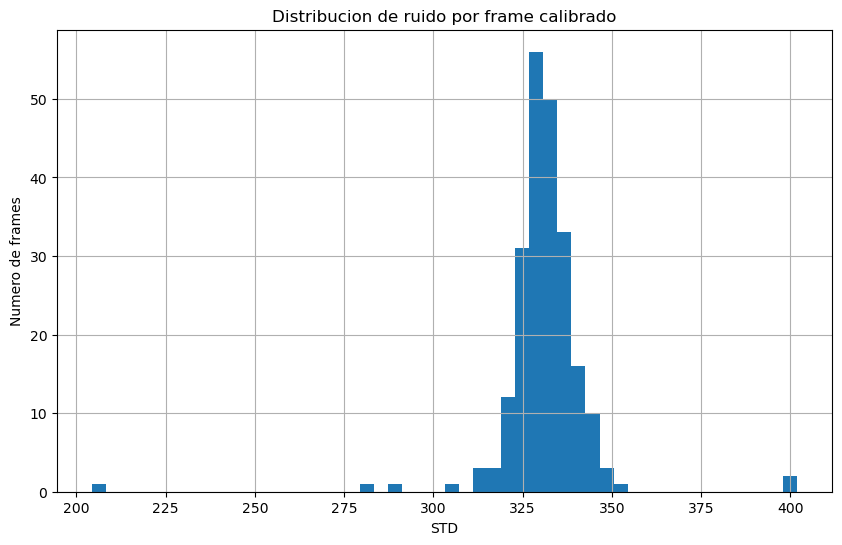

In [3]:
qc_df['std'].hist(bins=50, figsize=(10, 6))
plt.title('Distribucion de ruido por frame calibrado')
plt.xlabel('STD')
plt.ylabel('Numero de frames')
plt.show()

In [4]:
qc_df['quality_flag'].value_counts()

quality_flag
ok                        195
reject_high_background     29
Name: count, dtype: int64

In [6]:
calibrated_frame = reduction_io.load_ccd('../data/reduced/calibrated/cal_wasp-21-003red.fit')
not_calibrated_frame = reduction_io.load_ccd('../data/raw/wasp-21-003red.fit')

INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]


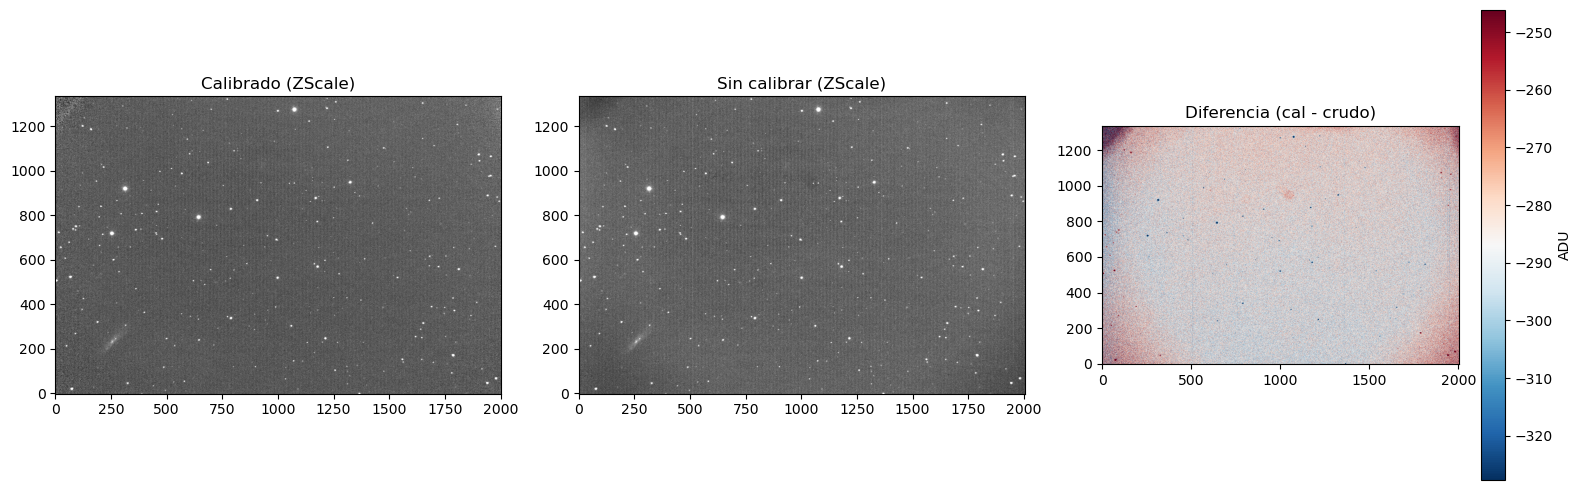

In [7]:

import numpy as np
import matplotlib.pyplot as plt
from astropy.visualization import ZScaleInterval

zscale = ZScaleInterval()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Frame calibrado con ZScale
vmin, vmax = zscale.get_limits(calibrated_frame.data)
axes[0].imshow(calibrated_frame.data, cmap='gray', vmin=vmin, vmax=vmax, origin='lower')
axes[0].set_title('Calibrado (ZScale)')

# Frame sin calibrar con ZScale
vmin2, vmax2 = zscale.get_limits(not_calibrated_frame.data)
axes[1].imshow(not_calibrated_frame.data, cmap='gray', vmin=vmin2, vmax=vmax2, origin='lower')
axes[1].set_title('Sin calibrar (ZScale)')

# Imagen diferencia
diff = calibrated_frame.data.astype(float) - not_calibrated_frame.data.astype(float)
vmin_d, vmax_d = np.percentile(diff, [1, 99])
im = axes[2].imshow(diff, cmap='RdBu_r', vmin=vmin_d, vmax=vmax_d, origin='lower')
axes[2].set_title('Diferencia (cal - crudo)')
plt.colorbar(im, ax=axes[2], label='ADU')

plt.tight_layout()
plt.show()


In [8]:
import ipywidgets as widgets
from ipywidgets import interact
import numpy as np
import matplotlib.pyplot as plt

data = calibrated_frame.data.astype(float)

# Rango total de los datos para los sliders
data_min = float(np.percentile(data, 0.1))
data_max = float(np.percentile(data, 99.9))

@interact(
    vmin_pct=widgets.FloatSlider(value=5.0, min=0, max=50, step=0.5,
                                  description='Fondo (%)', continuous_update=False),
    vmax_pct=widgets.FloatSlider(value=99.6, min=50, max=100, step=0.1,
                                  description='Brillo (%)', continuous_update=False),
    stretch=widgets.Dropdown(options=['linear', 'sqrt', 'log'], value='linear',
                              description='Escala'),
)
def mostrar_frame(vmin_pct, vmax_pct, stretch):
    vmin = float(np.percentile(data, vmin_pct))
    vmax = float(np.percentile(data, vmax_pct))

    if stretch == 'sqrt':
        display_data = np.sqrt(np.clip(data - vmin, 0, None))
        vmin_d, vmax_d = 0, np.sqrt(vmax - vmin)
    elif stretch == 'log':
        display_data = np.log1p(np.clip(data - vmin, 0, None))
        vmin_d, vmax_d = 0, np.log1p(vmax - vmin)
    else:
        display_data = data
        vmin_d, vmax_d = vmin, vmax

    fig, ax = plt.subplots(figsize=(8, 7))
    ax.imshow(display_data, cmap='gray', vmin=vmin_d, vmax=vmax_d, origin='lower')
    ax.set_title(f'Calibrado | fondo={vmin:.0f} ADU  brillo={vmax:.0f} ADU  escala={stretch}')
    ax.set_xlabel('Columna (px)')
    ax.set_ylabel('Fila (px)')
    plt.tight_layout()
    plt.show()

interactive(children=(FloatSlider(value=5.0, continuous_update=False, description='Fondo (%)', max=50.0, step=…

INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]


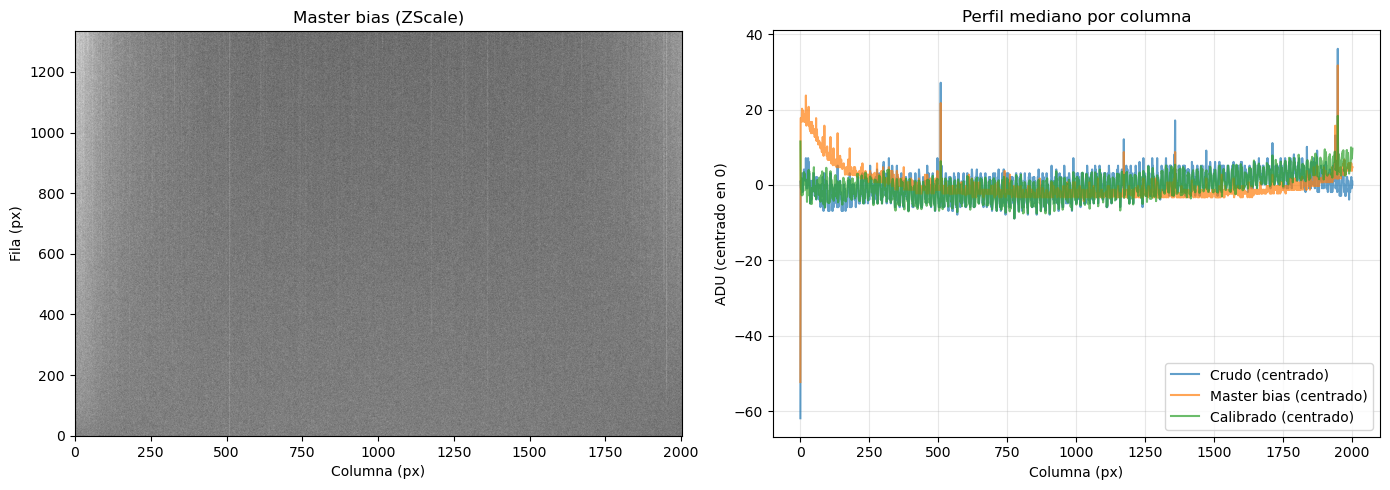

Amplitud patron columnas CRUDO:     98.0 ADU
Amplitud patron columnas CALIBRADO: 27.2 ADU
Reduccion del patron: 72.2%


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.visualization import ZScaleInterval

master_bias = reduction_io.load_ccd('../data/reduced/masters/master_bias.fits')

zscale = ZScaleInterval()
vmin_b, vmax_b = zscale.get_limits(master_bias.data)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Imagen del master bias con ZScale
axes[0].imshow(master_bias.data, cmap='gray', vmin=vmin_b, vmax=vmax_b, origin='lower')
axes[0].set_title('Master bias (ZScale)')
axes[0].set_xlabel('Columna (px)')
axes[0].set_ylabel('Fila (px)')

# Perfil mediano por columna (detecta patrones de lectura en columnas)
col_profile_bias = np.median(master_bias.data, axis=0)
col_profile_raw  = np.median(not_calibrated_frame.data.astype(float), axis=0)
col_profile_cal  = np.median(calibrated_frame.data.astype(float), axis=0)

axes[1].plot(col_profile_raw  - col_profile_raw.mean(),  alpha=0.7, label='Crudo (centrado)')
axes[1].plot(col_profile_bias - col_profile_bias.mean(), alpha=0.7, label='Master bias (centrado)')
axes[1].plot(col_profile_cal  - col_profile_cal.mean(),  alpha=0.7, label='Calibrado (centrado)')
axes[1].set_title('Perfil mediano por columna')
axes[1].set_xlabel('Columna (px)')
axes[1].set_ylabel('ADU (centrado en 0)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Cuantificacion: amplitud del patron antes y despues
amp_raw = col_profile_raw.max() - col_profile_raw.min()
amp_cal = col_profile_cal.max() - col_profile_cal.min()
print(f'Amplitud patron columnas CRUDO:     {amp_raw:.1f} ADU')
print(f'Amplitud patron columnas CALIBRADO: {amp_cal:.1f} ADU')
print(f'Reduccion del patron: {(1 - amp_cal/amp_raw)*100:.1f}%')